In [ ]:
!pip install unsloth
!pip install --force-reinstall --no-cache-dir --no-deps unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.2/403.2 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 129.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
import torch
print(f"PyTorch: {torch.__version__}")

PyTorch: 2.10.0+cu128


In [ ]:
from unsloth import FastLanguageModel

max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=None,
    load_in_4bit=True,
)

# Attach PEFT adapters for fine-tuning
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj",],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing=True,
    random_state=3407,
    max_seq_length=max_seq_length,
)

print("Model loaded successfully with PEFT adapters!")

==((====))==  Unsloth 2026.3.17: Fast Qwen2 patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

unsloth/qwen2.5-7b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.3.17 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model loaded successfully with PEFT adapters!


In [ ]:
import os
from google.colab import files

DATASET_PATH = "finetune_dataset.jsonl"

if not os.path.exists(DATASET_PATH):
    print("Upload file finetune_dataset.jsonl...")
    uploaded = files.upload()
    DATASET_PATH = list(uploaded.keys())[0]

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()
print(f"Số mẫu trong dataset: {len(lines)}")

Upload file finetune_dataset.jsonl...


Saving finetune_dataset.jsonl to finetune_dataset.jsonl
Số mẫu trong dataset: 862


In [ ]:
import json
from datasets import Dataset

def format_chat(sample):
    """Chuyển conversations sang chat template của Qwen."""
    messages = sample["conversations"]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

raw_data = []
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            raw_data.append(json.loads(line))

dataset = Dataset.from_list(raw_data)
dataset = dataset.map(format_chat)

print(f"Dataset size: {len(dataset)}")
print(f"\nVí dụ mẫu đầu tiên:\n{dataset[0]['text'][:500]}...")

Map:   0%|          | 0/862 [00:00<?, ? examples/s]

Dataset size: 862

Ví dụ mẫu đầu tiên:
<|im_start|>system
Ban la giao vien luyen thi TOEIC chuyen nghiep tai Viet Nam. Khi duoc cung cap tai lieu tham khao, hay su dung noi dung do de tao cau hoi chinh xac hon. Luon tra ve JSON hop le.<|im_end|>
<|im_start|>user
Dua vao tai lieu duoi day (co the bo sung kien thuc ben ngoai neu can).


--- Tai lieu (nguon: 01_tenses.txt) ---
# 12 Thì trong tiếng Anh (English Tenses)

## 1. Present Simple (Hiện tại đơn)
- Cấu trúc: S + V(s/es) | S + do/does + not + V
- Dùng khi: thói quen, sự thật, lịc...


In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        warmup_steps=5,
        num_train_epochs=3,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=42,
        output_dir="outputs",
        save_strategy="epoch",
    ),
)

print("Bắt đầu training...")
stats = trainer.train()
print(f"\nTraining hoàn tất!")
print(f"  Loss: {stats.training_loss:.4f}")
print(f"  Thời gian: {stats.metrics['train_runtime']:.0f}s")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/862 [00:00<?, ? examples/s]

Bắt đầu training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 862 | Num Epochs = 3 | Total steps = 324
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Step,Training Loss
10,1.771737
20,0.980653
30,0.726156
40,0.644253
50,0.571647
60,0.534841
70,0.490348
80,0.475846
90,0.439544
100,0.387730



Training hoàn tất!
  Loss: 0.3845
  Thời gian: 3587s


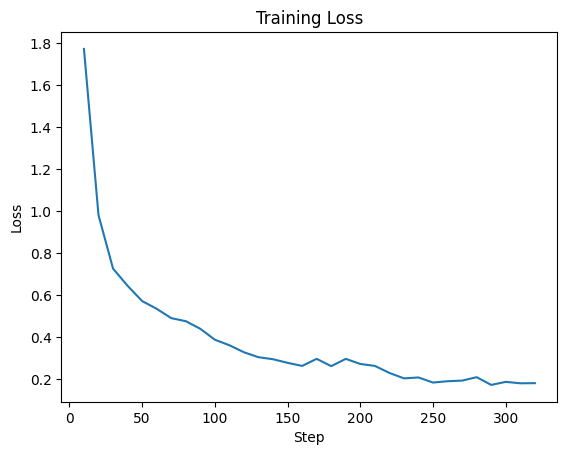

In [ ]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

steps, losses = [], []
for log in logs:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [ ]:
FastLanguageModel.for_inference(model)

test_prompts = [
    "Chọn đáp án đúng và giải thích chi tiết: 'Hardly ___ the meeting when the CEO announced a"
    "major restructuring.A. had we started B. we had started C. we started D. did we start,"
]

for prompt in test_prompts:
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(
        input_ids=inputs,
        max_length=max_seq_length, # Use max_seq_length directly
        temperature=0.7,
        do_sample=True,
        use_cache=False, # <--- Added this to debug rotary embedding issues
    )

    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True)
    print("=" * 60)
    print(f"Prompt: {prompt[:80]}...")
    print(f"\nResponse:\n{response}")
    print()

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


Prompt: Chọn đáp án đúng và giải thích chi tiết: 'Hardly ___ the meeting when the CEO an...

Response:
Đáp án đúng là A. "Hardly had we started".

Giải thích chi tiết:

1. **Cấu trúc "hardly...when"**: Đây là một cấu trúc đặc biệt trong tiếng Anh, thường dùng để mô tả hành động xảy ra gần như ngay lập tức sau khi một sự kiện khác xảy ra. Cấu trúc này yêu cầu sử dụng **thì quá khứ hoàn thành** (past perfect) cho phần trước "hardly" và **thì quá khứ đơn** (simple past) cho phần sau.

2. **Phân tích các lựa chọn**:
   - **A. Hardly had we started**: Đúng vì nó sử dụng thì quá khứ hoàn thành "had started" cho phần trước "hardly" và thì quá khứ đơn "started" cho phần sau "when".
   - **B. We had started**: Sai vì thiếu "hardly" ở đầu câu, và nếu chỉ dùng "We had started", nó sẽ không diễn tả hành động xảy ra gần như ngay lập tức.
   - **C. We started**: Sai vì thiếu "hardly" và không sử dụng thì quá khứ hoàn thành.
   - **D. Did we start**: Sai vì "did" là trợ động từ của thì hiện tại đơn, 

In [ ]:
model.push_to_hub("LeNhan18/ViEng-Qwen2.5-7B-lora")
tokenizer.push_to_hub("LeNhan18/ViEng-Qwen2.5-7B-lora")

README.md:   0%|          | 0.00/562 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 49.4kB /  162MB            

Saved model to https://huggingface.co/LeNhan18/ViEng-Qwen2.5-7B-lora


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpr9hy8svl/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            